In [ ]:
import requests

# Toronto Open Data is stored in a CKAN instance. It's APIs are documented here:
# https://docs.ckan.org/en/latest/api/

# To hit our API, you'll be making requests to:
base_url = "https://ckan0.cf.opendata.inter.prod-toronto.ca"

# Datasets are called "packages". Each package can contain many "resources"
# To retrieve the metadata for this package and its resources, use the package name in this page's URL:
url = base_url + "/api/3/action/package_show"
params = { "id": "toronto-raccoon-activity-index"}
package = requests.get(url, params = params).json()

# To get resource data:
for idx, resource in enumerate(package["result"]["resources"]):

       # To get metadata for non datastore_active resources:
       if not resource["datastore_active"]:
           url = base_url + "/api/3/action/resource_show?id=" + resource["id"]
           resource_metadata = requests.get(url).json()
           print(resource_metadata)
           # From here, you can use the "url" attribute to download this file

{'help': 'https://ckan0.cf.opendata.inter.prod-toronto.ca/api/3/action/help_show?name=resource_show', 'success': True, 'result': {'cache_last_updated': None, 'cache_url': None, 'created': '2026-04-01T11:35:50.299577', 'datastore_active': False, 'datastore_cache': [''], 'datastore_resource_id': '', 'format': 'CSV', 'hash': '', 'id': 'c6fcedc6-eb24-408e-930a-25723d00bade', 'is_datastore_cache_file': False, 'last_modified': '2026-04-01T11:35:49.793632', 'metadata_modified': '2026-04-01T11:35:51.315600', 'mimetype': 'text/csv', 'mimetype_inner': None, 'name': 'Toronto Raccoon Activity Index', 'package_id': '932c7dc1-d5c3-4740-995b-b5565d482584', 'position': 0, 'resource_type': None, 'size': 4124366, 'state': 'active', 'url': 'https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/932c7dc1-d5c3-4740-995b-b5565d482584/resource/c6fcedc6-eb24-408e-930a-25723d00bade/download/toronto_raccoon_activity_index_2024_q1.csv', 'url_type': 'upload'}}


In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df=pd.read_csv("https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/932c7dc1-d5c3-4740-995b-b5565d482584/resource/c6fcedc6-eb24-408e-930a-25723d00bade/download/Toronto%20Raccoon%20Activity%20Index.csv")


print(df.head())
print(df.columns)
print(df.dtypes)

              datetime        date  hour  ward_id            ward_name  \
0  2024-01-01 00:00:00  2024-01-01     0        1      Etobicoke North   
1  2024-01-01 00:00:00  2024-01-01     0        2     Etobicoke Centre   
2  2024-01-01 00:00:00  2024-01-01     0        3  Etobicoke-Lakeshore   
3  2024-01-01 00:00:00  2024-01-01     0        4   Parkdale-High Park   
4  2024-01-01 00:00:00  2024-01-01     0        5    York South-Weston   

   units_observed  bins_compromised  raccoon_confidence_level  \
0              12                 8                       7.7   
1              14                 8                       7.6   
2              15                 9                       7.7   
3              22                13                      10.0   
4               7                 9                       6.0   

   average_unit_weight_kg  incidents_of_raccoon_human_standoff  \
0                    5.53                                    2   
1                    5.67       

In [8]:
print(df.columns.tolist())
print(df.head())

['datetime', 'date', 'hour', 'ward_id', 'ward_name', 'units_observed', 'bins_compromised', 'raccoon_confidence_level', 'average_unit_weight_kg', 'incidents_of_raccoon_human_standoff', 'avg_standoff_duration_sec', 'proximity_to_a_patio', 'complaints_logged']
    datetime        date  hour  ward_id            ward_name  units_observed  \
0 2024-01-01  2024-01-01     0        1      Etobicoke North              12   
1 2024-01-01  2024-01-01     0        2     Etobicoke Centre              14   
2 2024-01-01  2024-01-01     0        3  Etobicoke-Lakeshore              15   
3 2024-01-01  2024-01-01     0        4   Parkdale-High Park              22   
4 2024-01-01  2024-01-01     0        5    York South-Weston               7   

   bins_compromised  raccoon_confidence_level  average_unit_weight_kg  \
0                 8                       7.7                    5.53   
1                 8                       7.6                    5.67   
2                 9                       

In [9]:
df['datetime'] = pd.to_datetime(df['datetime'])
df = df[(df['datetime'] >= '2024-01-01') & (df['datetime'] < '2024-04-01')]
ward_totals = df.groupby('ward_name')['units_observed'].sum().sort_values(ascending=False)

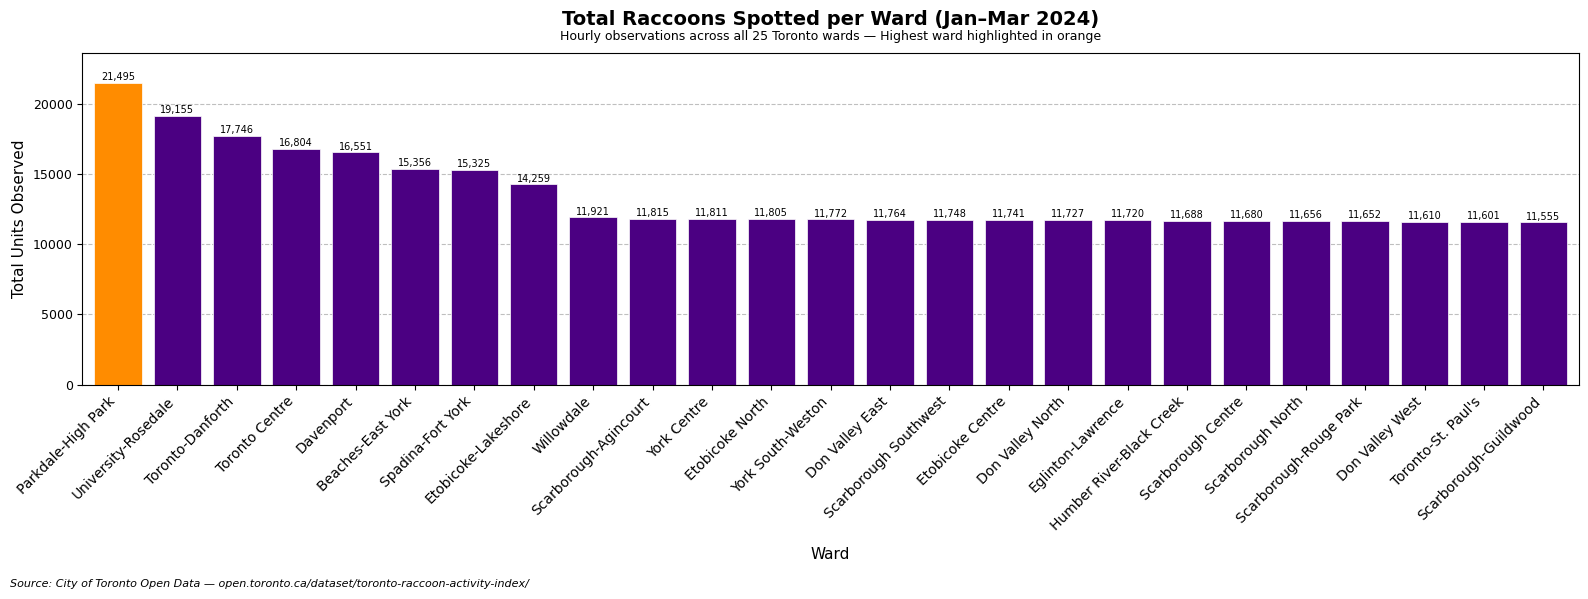

In [38]:
bar_colors = ['darkorange' if v == ward_totals.max() else 'indigo' for v in ward_totals.values]
fig, ax = plt.subplots(figsize=(16, 6))
bars = ax.bar(ward_totals.index, ward_totals.values, color=bar_colors, edgecolor='white', linewidth=0.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=7, color='black')
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='gray')
ax.set_axisbelow(True)
ax.set_title('Total Raccoons Spotted per Ward (Jan–Mar 2024)', fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.04, 'Hourly observations across all 25 Toronto wards — Highest ward highlighted in orange',
        transform=ax.transAxes, ha='center', fontsize=9, color='black')
ax.set_xlabel('Ward', fontsize=11, labelpad=10)
ax.set_ylabel('Total Units Observed', fontsize=11)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
ax.tick_params(axis='y', labelsize=9)
ax.set_xlim(-0.6, len(ward_totals) - 0.4)
ax.set_ylim(0, ward_totals.max() * 1.1)
fig.text(0.01, 0.01, 'Source: City of Toronto Open Data — open.toronto.ca/dataset/toronto-raccoon-activity-index/',
         ha='left', va='bottom', fontsize=8, color='black', style='italic')
plt.tight_layout(rect=[0, 0.03, 1, 1])
